<a href="https://colab.research.google.com/github/gilbramro/challenge1-data-science-latam/blob/main/alurastorelatam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importación de datos



In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
import pandas as pd
import matplotlib.pyplot as plt


url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [43]:
def ingreso_tienda(dataset):
  return dataset['Precio'].sum()

## Tienda 1

In [44]:
ingreso_total_tienda1 = ingreso_tienda(tienda)
ingreso_total_tienda1

np.float64(1150880400.0)

## Tienda 2

In [46]:
ingreso_total_tienda2 = ingreso_tienda(tienda2)
ingreso_total_tienda2

np.float64(1116343500.0)

## Tienda 3

In [47]:
ingreso_total_tienda3 = ingreso_tienda(tienda3)
ingreso_total_tienda3

np.float64(1098019600.0)

## Tienda 4

In [48]:
ingreso_total_tienda4 = ingreso_tienda(tienda4)
ingreso_total_tienda4

np.float64(1038375700.0)

In [49]:
def unificar_datos(serie1, serie2, serie3, serie4, nombreColumna):
  series = {'tienda1' : serie1,
            'tienda2' : serie2,
            'tienda3' : serie3,
            'tienda4' : serie4}
  return pd.Series(series, name = nombreColumna )

In [50]:
ingresos_totales = unificar_datos(ingreso_total_tienda1, ingreso_total_tienda2, ingreso_total_tienda3, ingreso_total_tienda4, 'Ingresos').astype(int)

ingresos_totales

,Ingresos
tienda1,1150880400
tienda2,1116343500
tienda3,1098019600
tienda4,1038375700


## Grafico de Barras

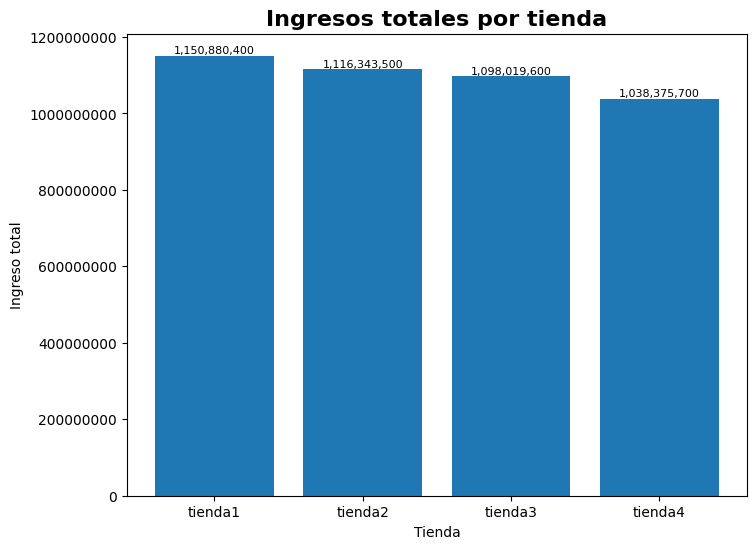

In [53]:

fig, ingresos = plt.subplots(1, figsize=(8,6))
ingresos.bar(ingresos_totales.index, ingresos_totales.values)
ingresos.set_title("Ingresos totales por tienda", fontsize=16, fontweight='bold')
ingresos.set_xlabel("Tienda")
ingresos.set_ylabel("Ingreso total")

for i, valor in enumerate(ingresos_totales.values):
  ingresos.text(i, valor+1, f'{valor:,.0f}', ha='center', va='bottom', fontsize = 8, color='black' )

ingresos.ticklabel_format(style='plain', axis='y')

# 2. Ventas por categoría

In [23]:
def agrupar_categoria(dataset):
  return dataset.groupby('Categoría del Producto')['Producto'].count().sort_values(ascending=False)

### **Tienda** 1 ###

In [26]:
tienda1_categorias = agrupar_categoria(tienda)
tienda1_categorias

,Producto
Categoría del Producto,
Muebles,465
Electrónicos,448
Juguetes,324
Electrodomésticos,312
Deportes y diversión,284
Instrumentos musicales,182
Libros,173
Artículos para el hogar,171


### **Tienda** 2 ###

In [27]:
tienda2_categorias = agrupar_categoria(tienda2)
tienda2_categorias

,Producto
Categoría del Producto,
Muebles,442
Electrónicos,422
Juguetes,313
Electrodomésticos,305
Deportes y diversión,275
Instrumentos musicales,224
Libros,197
Artículos para el hogar,181


### **Tienda** 3 ###

In [28]:
tienda3_categorias = agrupar_categoria(tienda3)
tienda3_categorias

,Producto
Categoría del Producto,
Muebles,499
Electrónicos,451
Juguetes,315
Electrodomésticos,278
Deportes y diversión,277
Libros,185
Artículos para el hogar,177
Instrumentos musicales,177


### **Tienda** 4 ###

In [29]:
tienda4_categorias = agrupar_categoria(tienda4)
tienda4_categorias

,Producto
Categoría del Producto,
Muebles,480
Electrónicos,451
Juguetes,338
Deportes y diversión,277
Electrodomésticos,254
Artículos para el hogar,201
Libros,187
Instrumentos musicales,170


## **Grafico de torta con la distribución de las ventas por categoría de producto** ##

Text(0.5, -0.2, 'Tienda 4')

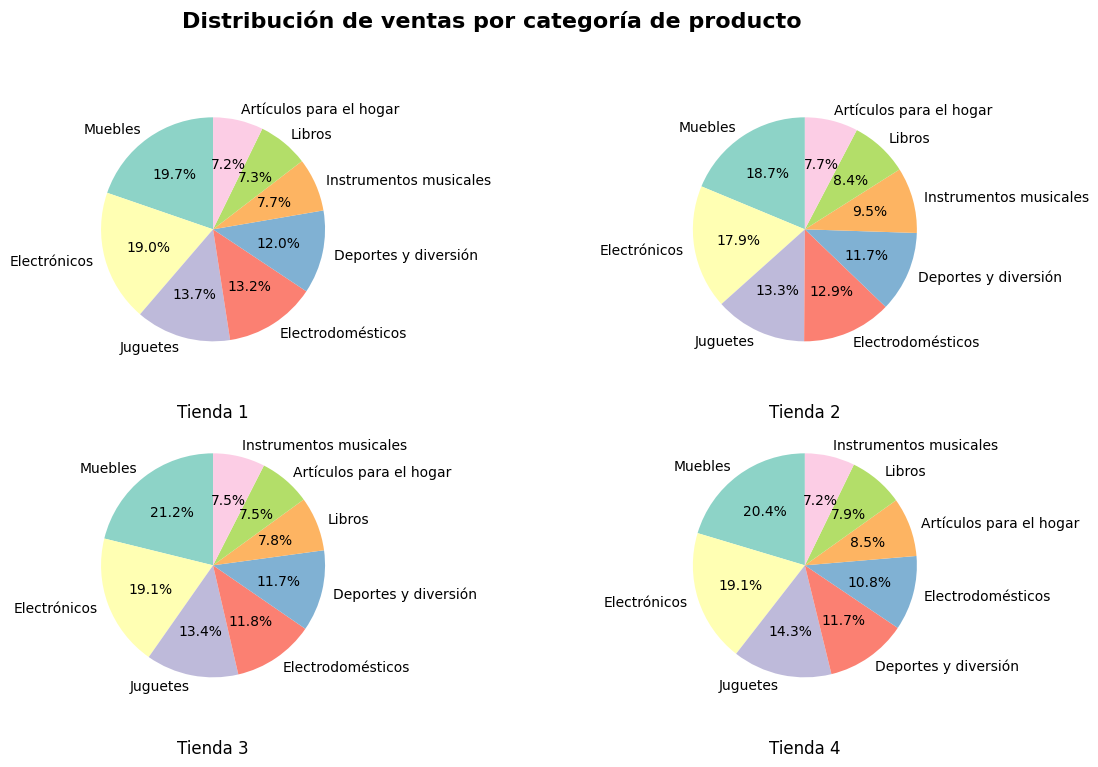

In [31]:
fig1, categoria = plt.subplots(2, 2, figsize=(14,8))
fig1.suptitle("Distribución de ventas por categoría de producto", fontsize = 16, fontweight='bold')

categoria[0,0].pie(tienda1_categorias, labels = tienda1_categorias.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Set3.colors)
categoria[0,0].set_title('Tienda 1', y=-0.2)
categoria[0,1].pie(tienda2_categorias, labels = tienda2_categorias.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Set3.colors)
categoria[0,1].set_title('Tienda 2', y=-0.2)
categoria[1,0].pie(tienda3_categorias, labels = tienda3_categorias.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Set3.colors)
categoria[1,0].set_title('Tienda 3', y=-0.2)
categoria[1,1].pie(tienda4_categorias, labels = tienda4_categorias.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Set3.colors)
categoria[1,1].set_title('Tienda 4', y=-0.2)



# 3. Calificacion promedio de la tienda

In [32]:
def promedio_calificacion(dataset):
  return dataset['Calificación'].mean()

## Tienda 1

In [33]:
calificacion_promedio_tienda1 = promedio_calificacion(tienda)
calificacion_promedio_tienda1

np.float64(3.976685036032217)

## Tienda 2

In [34]:
calificacion_promedio_tienda2 = promedio_calificacion(tienda2)
calificacion_promedio_tienda2

np.float64(4.037303942348453)

## Tienda 3

In [35]:
calificacion_promedio_tienda3 = promedio_calificacion(tienda3)
calificacion_promedio_tienda3

np.float64(4.048325561678677)

## Tienda 4

In [36]:
calificacion_promedio_tienda4 = promedio_calificacion(tienda4)
calificacion_promedio_tienda4

np.float64(3.9957591178965224)

In [42]:
calificaciones_promedio = unificar_datos(calificacion_promedio_tienda1, calificacion_promedio_tienda2, calificacion_promedio_tienda3, calificacion_promedio_tienda4, 'Calificación')
calificaciones_promedio

,Calificación
tienda1,3.976685
tienda2,4.037304
tienda3,4.048326
tienda4,3.995759


## Grafico de Puntos

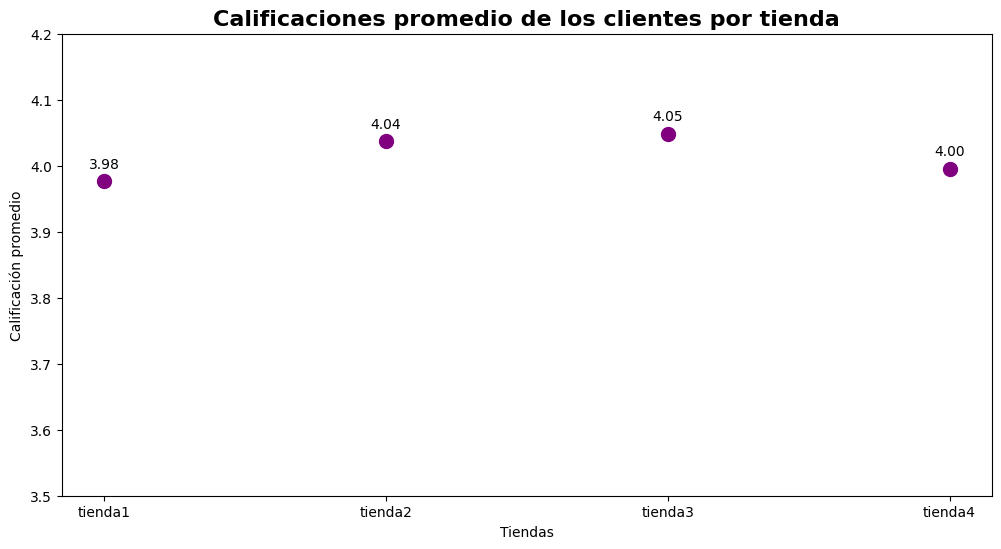

In [60]:
fig2, calificacion = plt.subplots(figsize=(12,6))
calificacion.scatter(calificaciones_promedio.index, calificaciones_promedio.values, color='purple', s=100)
calificacion.set_title("Calificaciones promedio de los clientes por tienda", fontsize=16, fontweight= 'bold')
calificacion.set_xlabel("Tiendas")
calificacion.set_ylabel("Calificación promedio")
calificacion.set_ylim(3.5,4.2) # Limita el rango del eje y

for i, valor in enumerate(calificaciones_promedio.values):
  calificacion.text(i, valor+0.02, f'{valor:.2f}', ha='center')

# 4. Productos más y menos vendidos

In [91]:
# Función con los 3 productos más vendidos y su respectiva cantidad vendida
def prod_mas_vendidos(dataset):
  return dataset.groupby('Producto').size().reset_index(name='Cantidad Vendida').sort_values('Cantidad Vendida', ascending=False).head(3)

# Función con los 3 productos menos vendidos y su respectiva cantidad vendida
def pro_menos_vendidos(dataset):
  return dataset.groupby('Producto').size().reset_index(name='Cantidad Vendida').sort_values('Cantidad Vendida', ascending=True).head(3)


## Top 3 Tienda 1 + Vendidos

In [62]:
prod_mas_vendidos_tienda1 = prod_mas_vendidos(tienda)
prod_mas_vendidos_tienda1

,Producto,Cantidad Vendida
1,Armario,60
48,TV LED UHD 4K,60
33,Microondas,60


## Top 3 Tienda 1 - Vendidos

In [63]:
prod_menos_vendidos_tienda1 = pro_menos_vendidos(tienda)
prod_menos_vendidos_tienda1

,Producto,Cantidad Vendida
4,Auriculares con micrófono,33
13,Celular ABXY,33
37,Olla de presión,35


## Top 3 Tienda 2 + Vendidos

In [64]:

prod_mas_vendidos_tienda2 = prod_mas_vendidos(tienda2)
prod_mas_vendidos_tienda2

,Producto,Cantidad Vendida
24,Iniciando en programación,65
33,Microondas,62
7,Batería,61


## Top 3 Tienda 2 - Vendidos

In [65]:
prod_menos_vendidos_tienda2 = pro_menos_vendidos(tienda2)
prod_menos_vendidos_tienda2

,Producto,Cantidad Vendida
26,Juego de mesa,32
23,Impresora,34
31,Mesa de comedor,34


## Top 3 Tienda 3 + Vendidos

In [66]:
prod_mas_vendidos_tienda3 = prod_mas_vendidos(tienda3)
prod_mas_vendidos_tienda3

,Producto,Cantidad Vendida
27,Kit de bancas,57
31,Mesa de comedor,56
11,Cama king,56


## Top 3 Tienda 3 - Vendidos

In [67]:
prod_menos_vendidos_tienda3 = pro_menos_vendidos(tienda3)
prod_menos_vendidos_tienda3

,Producto,Cantidad Vendida
9,Bloques de construcción,35
42,Set de vasos,36
34,Mochila,36


## Top 3 Tienda 4 + Vendidos

In [68]:

prod_mas_vendidos_tienda4 = prod_mas_vendidos(tienda4)
prod_mas_vendidos_tienda4

,Producto,Cantidad Vendida
10,Cama box,62
15,Cubertería,59
11,Cama king,56


## Top 3 Tienda 4 - Vendidos

In [69]:
prod_menos_vendidos_tienda4 = pro_menos_vendidos(tienda4)
prod_menos_vendidos_tienda4

,Producto,Cantidad Vendida
22,Guitarra eléctrica,33
1,Armario,34
21,Guitarra acústica,37


## Grafico de barras horizontales productos más y menos vendidos por tienda

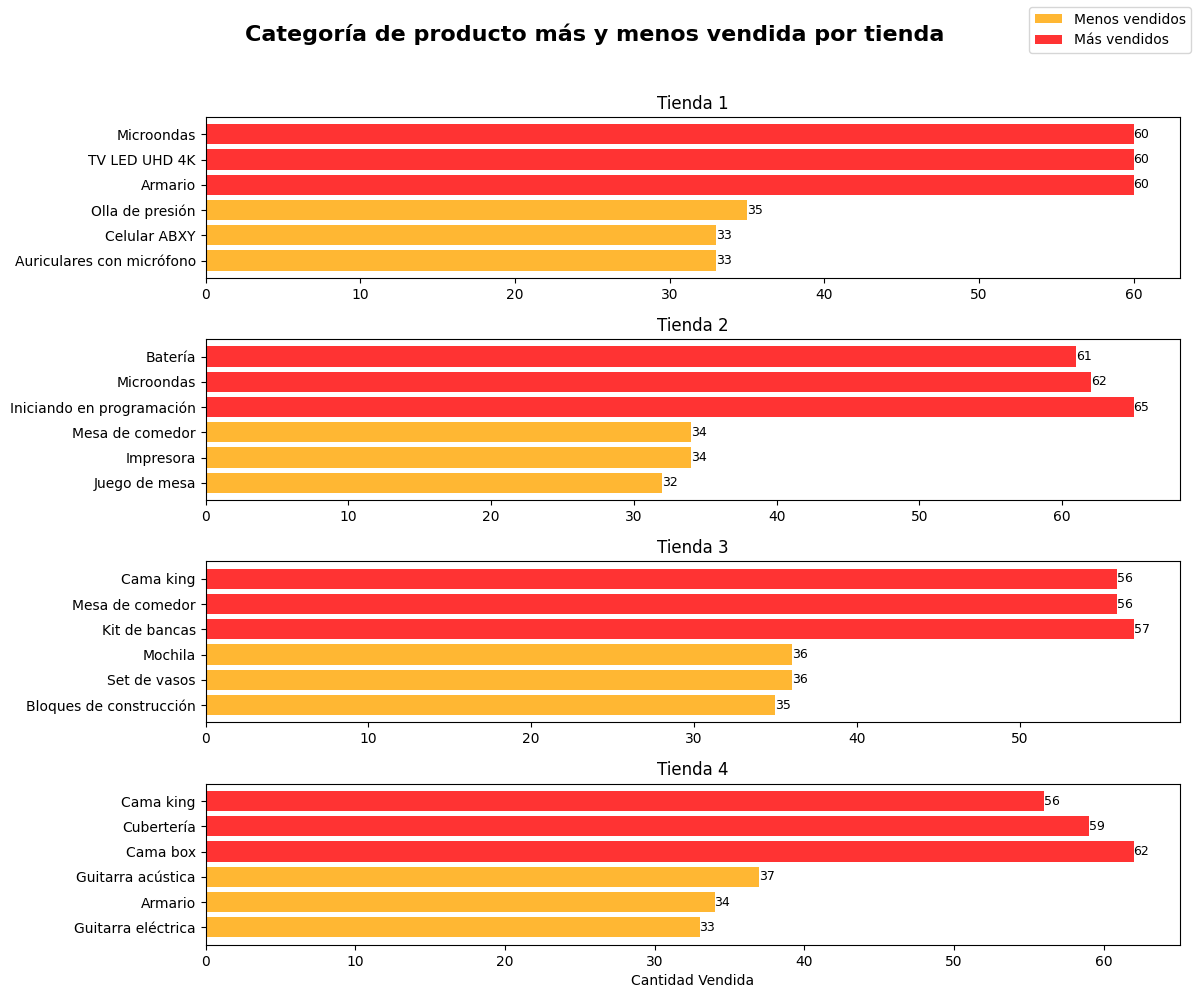

In [93]:

fig3, productos= plt.subplots(4,1, figsize=(12,10))
fig3.suptitle('Categoría de producto más y menos vendida por tienda', fontsize = 16, fontweight='bold')

productos[0].barh(prod_menos_vendidos_tienda1['Producto'], prod_menos_vendidos_tienda1['Cantidad Vendida'], color='orange', alpha=0.8)
productos[0].barh(prod_mas_vendidos_tienda1['Producto'], prod_mas_vendidos_tienda1['Cantidad Vendida'], color='red', alpha=0.8)
productos[0].set_title('Tienda 1')

productos[1].barh(prod_menos_vendidos_tienda2['Producto'], prod_menos_vendidos_tienda2['Cantidad Vendida'], color='orange', alpha=0.8)
productos[1].barh(prod_mas_vendidos_tienda2['Producto'], prod_mas_vendidos_tienda2['Cantidad Vendida'], color='red', alpha=0.8)
productos[1].set_title('Tienda 2')

productos[2].barh(prod_menos_vendidos_tienda3['Producto'], prod_menos_vendidos_tienda3['Cantidad Vendida'], color='orange', alpha=0.8)
productos[2].barh(prod_mas_vendidos_tienda3['Producto'], prod_mas_vendidos_tienda3['Cantidad Vendida'], color='red', alpha=0.8)
productos[2].set_title('Tienda 3')

productos[3].barh(prod_menos_vendidos_tienda4['Producto'], prod_menos_vendidos_tienda4['Cantidad Vendida'], color='orange', alpha=0.8)
productos[3].barh(prod_mas_vendidos_tienda4['Producto'], prod_mas_vendidos_tienda4['Cantidad Vendida'], color='red', alpha=0.8)
productos[3].set_title('Tienda 4')
productos[3].set_xlabel('Cantidad Vendida')

for ax in productos:
  for bars in ax.containers:
    ax.bar_label(bars,fmt='%.0f',label_type='edge',fontsize=9)


fig3.legend(['Menos vendidos', 'Más vendidos'], loc='upper right')
plt.tight_layout(rect=[0,0,1,0.96]) # Para ajustar la imagen y que no se superpongan elementos


In [71]:
#Lista donde cada elemento es la diferencia entre el producto más vendido y menos vendido por tienda
var_ventas_productos = [('tienda1', tienda['Producto'].value_counts()['Armario'] - tienda['Producto'].value_counts()['Auriculares con micrófono']),
                        ('tienda2',tienda2['Producto'].value_counts()['Iniciando en programación'] - tienda2['Producto'].value_counts()['Juego de mesa']),
                        ('tienda3',tienda3['Producto'].value_counts()['Kit de bancas'] - tienda3['Producto'].value_counts()['Bloques de construcción']),
                        ('tienda4',tienda4['Producto'].value_counts()['Cama box'] - tienda4['Producto'].value_counts()['Guitarra eléctrica'])]
# La lista anterior la usamos para crear el DatFrame "concentracion_ventas"
concentracion_ventas = pd.DataFrame(var_ventas_productos, columns=['Tienda', 'Diversificación de ventas']).set_index('Tienda')
concentracion_ventas.sort_values(by='Diversificación de ventas', ascending=False)

,Diversificación de ventas
Tienda,
tienda2,33
tienda4,29
tienda1,27
tienda3,22


# 5. Envío promedio por tienda

## Tienda 1

In [72]:
costo_envio_promedio_tienda1 = tienda['Costo de envío'].mean()
costo_envio_promedio_tienda1

np.float64(26018.60958033065)

## Tienda 2

In [73]:
costo_envio_promedio_tienda2 = tienda2['Costo de envío'].mean()
costo_envio_promedio_tienda2

np.float64(25216.235693090293)

## Tienda 3

In [74]:

costo_envio_promedio_tienda3 = tienda3['Costo de envío'].mean()
costo_envio_promedio_tienda3

np.float64(24805.680373039424)

## Tienda 4

In [75]:

costo_envio_promedio_tienda4 = tienda4['Costo de envío'].mean()
costo_envio_promedio_tienda4

np.float64(23459.457167090754)

In [76]:

costo_envio_promedio = unificar_datos(costo_envio_promedio_tienda1, costo_envio_promedio_tienda2, costo_envio_promedio_tienda3, costo_envio_promedio_tienda4, 'Costo de envío promedio').astype(int)
costo_envio_promedio


,Costo de envío promedio
tienda1,26018
tienda2,25216
tienda3,24805
tienda4,23459


## Histograma  costo  envío por tienda

Text(0.5, 58.7222222222222, 'Costo del envío')

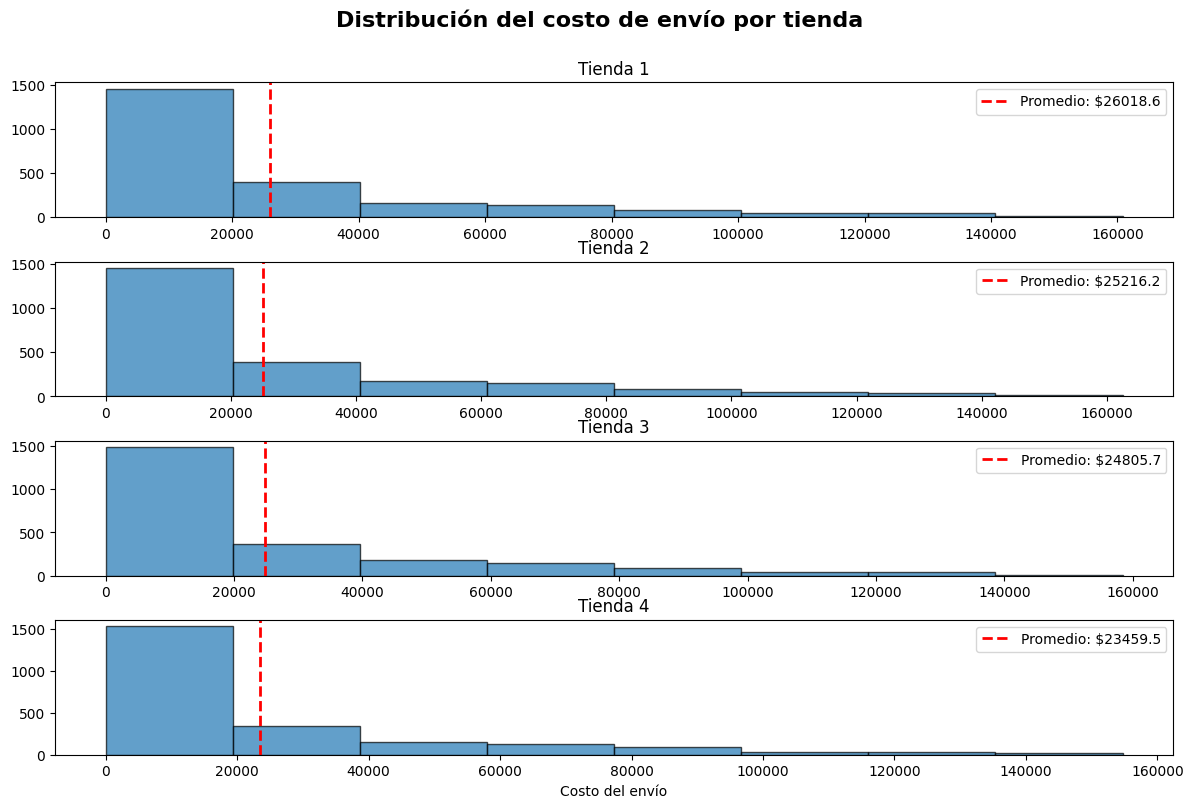

In [77]:
fig4, evaluacion = plt.subplots(4, figsize=(12,8))
fig4.suptitle('Distribución del costo de envío por tienda', fontsize = 16, fontweight='bold')
plt.tight_layout(rect=[0,0,1,0.96])

evaluacion[0].hist(tienda['Costo de envío'], bins=8, edgecolor='black', alpha=0.7)
evaluacion[0].axvline(costo_envio_promedio_tienda1, color='red', linestyle='--', linewidth=2, label=f'Promedio: ${costo_envio_promedio_tienda1:.1f}')
evaluacion[0].set_title('Tienda 1')
evaluacion[0].legend()

evaluacion[1].hist(tienda2['Costo de envío'], bins=8, edgecolor='black', alpha=0.7)
evaluacion[1].axvline(costo_envio_promedio_tienda2, color='red', linestyle='--', linewidth=2, label=f'Promedio: ${costo_envio_promedio_tienda2:.1f}')
evaluacion[1].set_title('Tienda 2')
evaluacion[1].legend()

evaluacion[2].hist(tienda3['Costo de envío'], bins=8, edgecolor='black', alpha=0.7)
evaluacion[2].axvline(costo_envio_promedio_tienda3, color='red', linestyle='--', linewidth=2, label=f'Promedio: ${costo_envio_promedio_tienda3:.1f}')
evaluacion[2].set_title('Tienda 3')
evaluacion[2].legend()

evaluacion[3].hist(tienda4['Costo de envío'], bins=8, edgecolor='black', alpha=0.7)
evaluacion[3].axvline(costo_envio_promedio_tienda4, color='red', linestyle='--', linewidth=2, label=f'Promedio: ${costo_envio_promedio_tienda4:.1f}')
evaluacion[3].set_title('Tienda 4')
evaluacion[3].legend()
evaluacion[3].set_xlabel('Costo del envío')

## Análisis del desempeño geográfico

In [78]:
lat_tienda1 = tienda['lat']
lon_tienda1 = tienda['lon']

lat_tienda2 = tienda2['lat']
lon_tienda2 = tienda2['lon']

lat_tienda3 = tienda3['lat']
lon_tienda3 = tienda3['lon']

lat_tienda4 = tienda4['lat']
lon_tienda4 = tienda4['lon']

# Variable para luego normalizar el tamaño de los puntos y que sea comparable entre las tiendas
precio_max_global = max(
    tienda['Precio'].max(),
    tienda2['Precio'].max(),
    tienda3['Precio'].max(),
    tienda4['Precio'].max()
)


In [79]:
pip install contextily

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 91.9 MB/s eta 0:00:00


In [80]:
from ctypes import c_int16
from matplotlib.colors import ListedColormap
import numpy as np
import geopandas as gpd
import contextily as cx

In [94]:
# Función para crear los mapas de calor, los parametros son: el DataFrame de la tienda, las longitudes, las latitudes, N° de tienda y la variable "precio_max_global"
def crear_heatmap(dataset, lon,lat, numTienda, precio_max_global):
  gdf = gpd.GeoDataFrame(dataset, geometry=gpd.points_from_xy(lon, lat), crs="EPSG:4326")
  gdf = gdf.to_crs(epsg=3857)

  x = gdf.geometry.x.values
  y = gdf.geometry.y.values
  nbins= 300

  H, xedges, yedges = np.histogram2d(x,y, bins=nbins)
  H = H.T
  extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]] # Para encuadrar bien todas las capas

  colores = ['#F54927', '#C23F25', '#994737', '#8A665F', '#B0AA38']
  cmap = ListedColormap(colores)

  # Este bloque de codigo es para que luego no se superpongan los puntos en el mapa
  np.random.seed(42)
  jitter = 100
  x_jitter = x + np.random.uniform(-jitter, jitter, size=len(x))
  y_jitter = y + np.random.uniform(-jitter, jitter, size=len(y))


  fig5, ax = plt.subplots(figsize=(11,11))
  ax.imshow(H, extent=extent, origin='lower', alpha=0.45, cmap='Greys', aspect='auto')
  #Scatter donde configuramos el color de puntos en base a la calificación y el tamaño en base a la venta en esa zona
  scatter = ax.scatter(x_jitter, y_jitter, s=(gdf['Precio']/precio_max_global)*220, c=gdf['Calificación'], cmap=cmap, alpha=0.9, edgecolor='black', linewidth=0.2, zorder=5)

  #Mapa
  cx.add_basemap(ax, crs=gdf.crs.to_string(), source=cx.providers.OpenStreetMap.Mapnik, alpha=0.7)
  ax.set_axis_off()

  #Barra al costado del grafico
  cbar = plt.colorbar(scatter, ax=ax, ticks=[1,2,3,4,5], shrink=0.7,pad=0.01)
  cbar.ax.set_yticklabels(['1', '2', '3', '4', '5'])
  cbar.set_label('Calificación del cliente', fontsize=11)

  #Leyenda con los ingresos que representa cada tamaño de punto
  precios_leyenda = [gdf['Precio'].min(), gdf['Precio'].median(), gdf['Precio'].max()]
  for precio in precios_leyenda:
    ax.scatter([], [], s=(precio/gdf['Precio'].max())*220,
              c='gray', alpha=0.5, edgecolor= 'black', linewidth=0.3, label=f'${precio:,.0f}')
  leg = ax.legend(scatterpoints=1, frameon=True, labelspacing= 1, title='Ingresos por zona', loc='lower left', fontsize=9, title_fontsize=10, facecolor='white')
  leg.get_frame().set_edgecolor('black')


  plt.title(f"Mapa de calor con Calificación (color) e Ingreso (tamaño)\nTienda {numTienda}", fontsize=14, fontweight='bold', color='darkblue')
  plt.tight_layout()

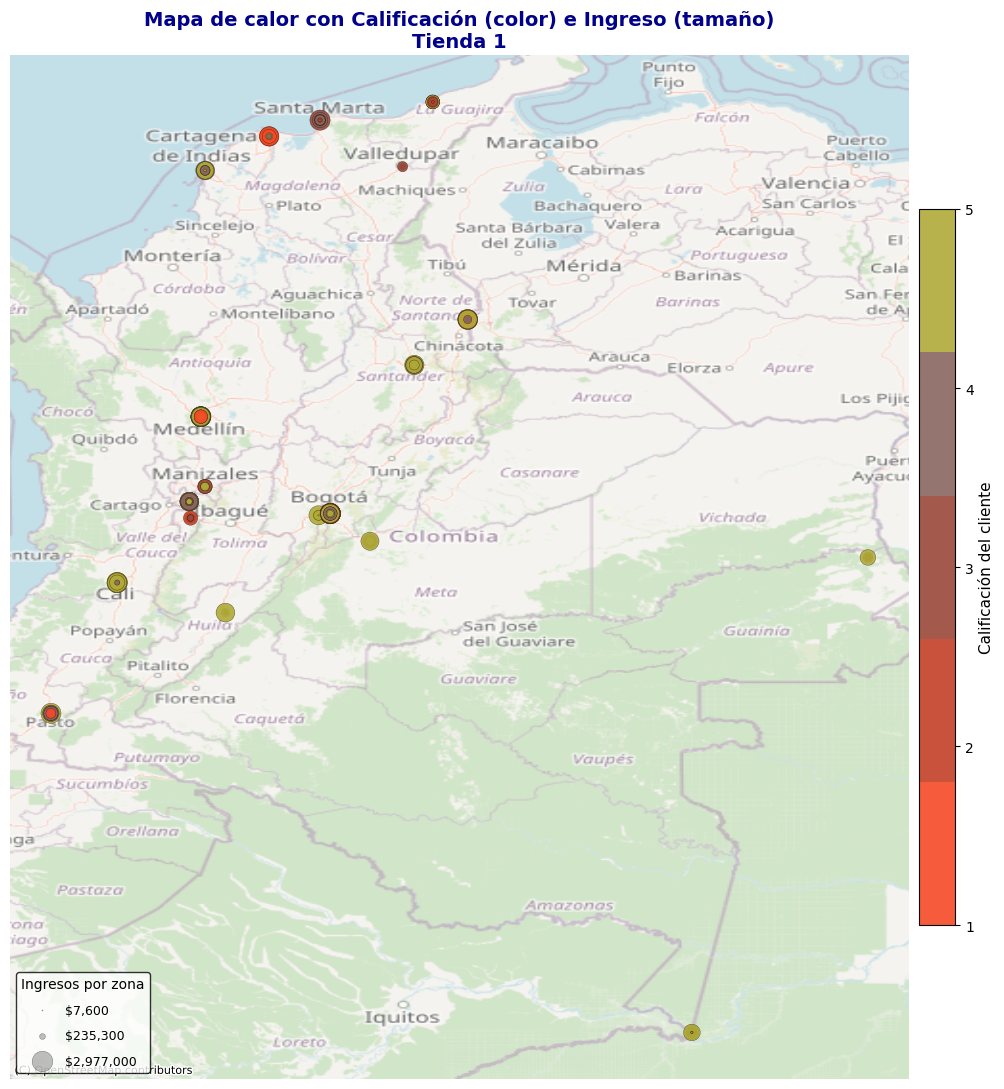

In [95]:

crear_heatmap(tienda, lon_tienda1, lat_tienda1, 1, precio_max_global)

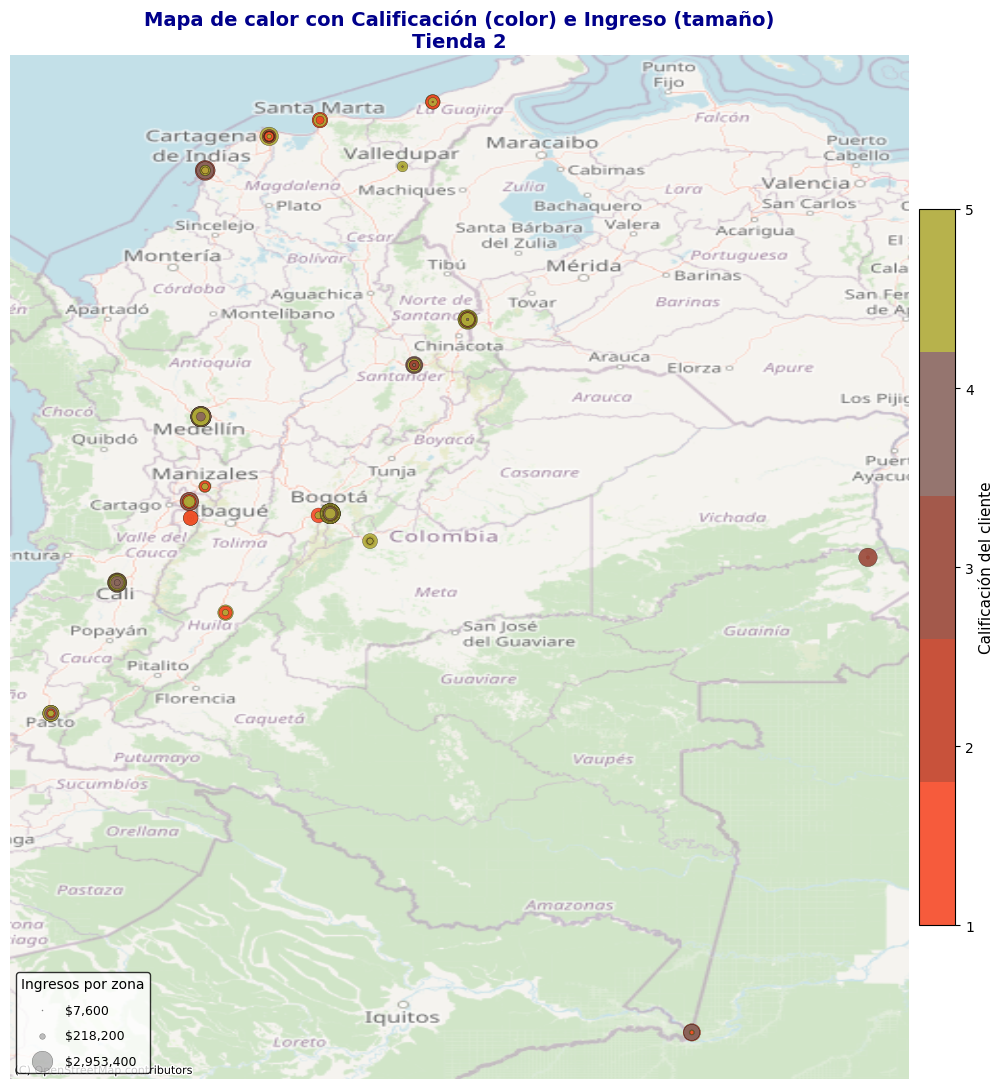

In [96]:
crear_heatmap(tienda2, lon_tienda2, lat_tienda2, 2, precio_max_global)

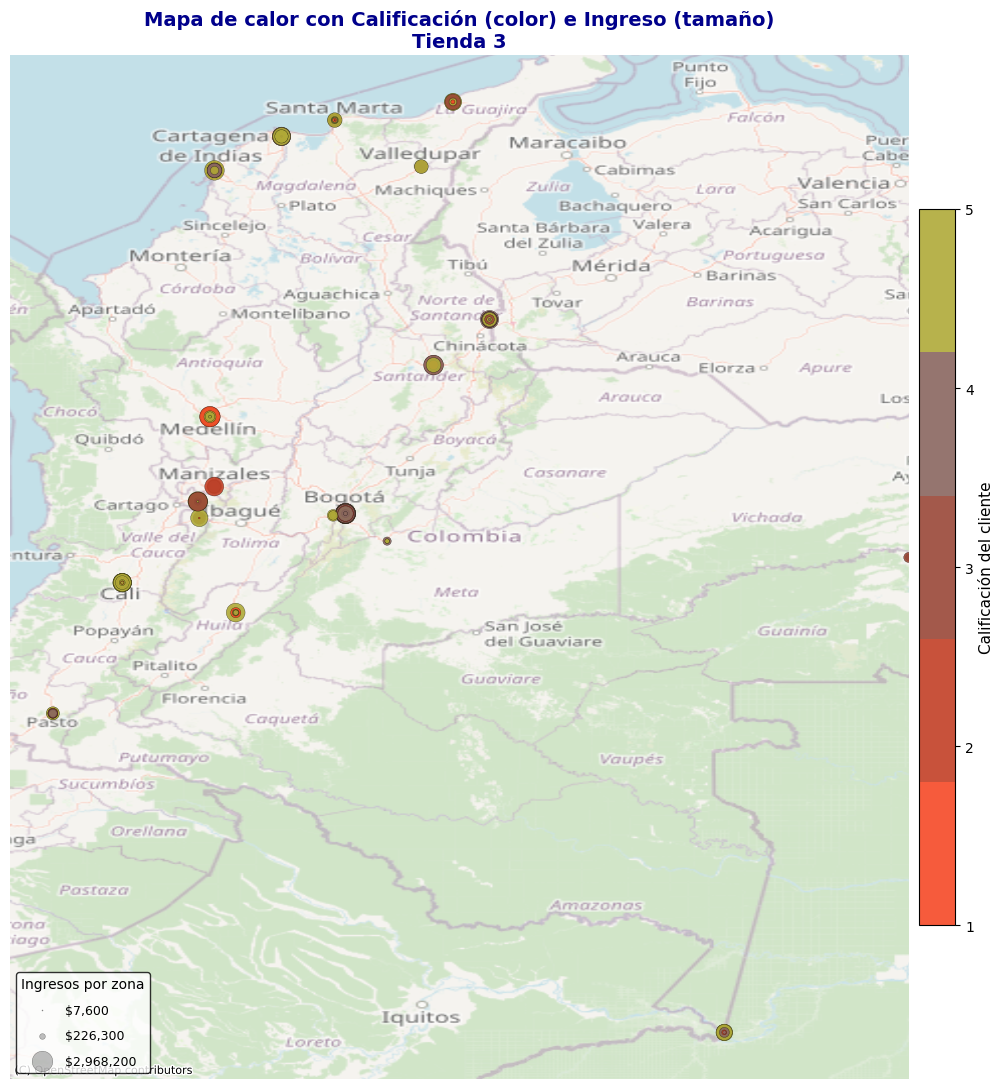

In [97]:

crear_heatmap(tienda3, lon_tienda3, lat_tienda3, 3, precio_max_global)

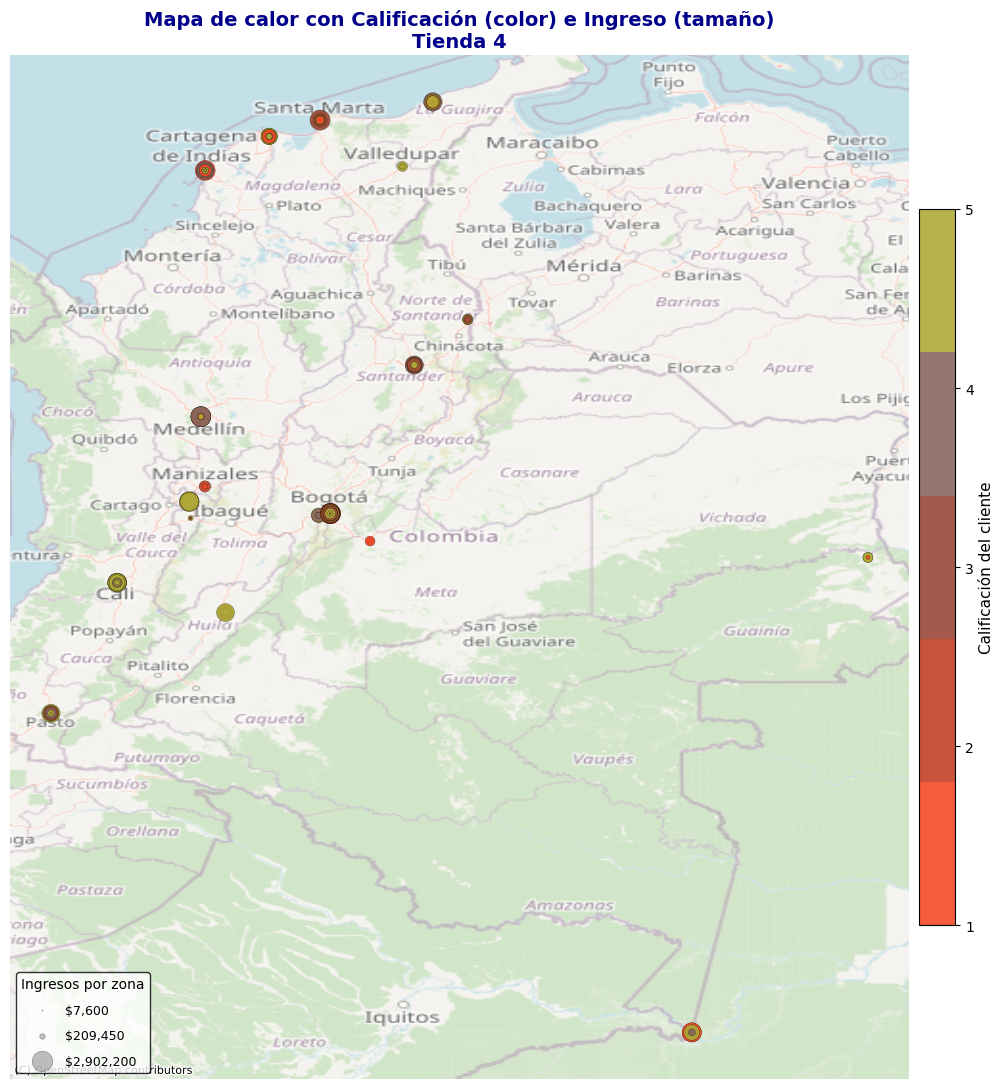

In [98]:
crear_heatmap(tienda4, lon_tienda4, lat_tienda4, 4, precio_max_global)

## Conclusión

In [86]:
resumen = [ingresos_totales, calificaciones_promedio, concentracion_ventas, costo_envio_promedio]

In [87]:
tabla_resumen = pd.concat(resumen, axis=1 )
tabla_resumen

,Ingresos,Calificación,Diversificación de ventas,Costo de envío promedio
tienda1,1150880400,3.976685,27,26018
tienda2,1116343500,4.037304,33,25216
tienda3,1098019600,4.048326,22,24805
tienda4,1038375700,3.995759,29,23459


## Tabla Normalizada

In [88]:
for titulo in tabla_resumen:
  if titulo == 'Ingresos':
    nor_ingresos = [(tabla_resumen.loc[i, titulo] - tabla_resumen[titulo].min()) / (tabla_resumen[titulo].max()- tabla_resumen[titulo].min()) * 100 for i in ['tienda1','tienda2','tienda3','tienda4']]
  elif titulo == 'Calificación':
    nor_calificacion = [(tabla_resumen.loc[i, titulo] - tabla_resumen[titulo].min()) / (tabla_resumen[titulo].max()- tabla_resumen[titulo].min()) * 100 for i in ['tienda1','tienda2','tienda3','tienda4']]
  elif titulo == 'Diversificación de ventas':
    nor_diversificacion = [(tabla_resumen[titulo].max() - tabla_resumen.loc[i, titulo]) / (tabla_resumen[titulo].max()- tabla_resumen[titulo].min()) * 100 for i in ['tienda1','tienda2','tienda3','tienda4']]
  else:
    nor_costo_envio = [(tabla_resumen[titulo].max() - tabla_resumen.loc[i, titulo]) / (tabla_resumen[titulo].max()- tabla_resumen[titulo].min()) * 100 for i in ['tienda1','tienda2','tienda3','tienda4']]

normalizacion = {'Tienda' : ['tienda1','tienda2','tienda3','tienda4'],
                 'Ingresos': nor_ingresos,
                 'Calificación' : nor_calificacion,
                 'Diversificación' : nor_diversificacion,
                 'Costo de envío' : nor_costo_envio}

tabla_normalizada = pd.DataFrame(normalizacion).set_index('Tienda')
tabla_normalizada

,Ingresos,Calificación,Diversificación,Costo de envío
Tienda,,,,
tienda1,100.000000,0.000000,54.545455,0.000000
tienda2,69.301816,84.615385,0.000000,31.340367
tienda3,53.014585,100.000000,100.000000,47.401329
tienda4,0.000000,26.624710,36.363636,100.000000


## Ponderacion

In [89]:
ponderacion = { 'Criterio' : ['Ingresos', 'Calificación', 'Diversificación de ventas', 'Costo de envío'], 'Ponderación': [0.3, 0.25, 0.25, 0.2]}
ponderaciones = pd.DataFrame(ponderacion)
ponderaciones


,Criterio,Ponderación
0,Ingresos,0.30
1,Calificación,0.25
2,Diversificación de ventas,0.25
3,Costo de envío,0.20


## Puntuacion

In [90]:
for titulo in tabla_normalizada:
  if titulo == 'Ingresos':
    puntos_ingresos = [tabla_normalizada.loc[i, titulo] * ponderaciones.loc[0, 'Ponderación'] for i in ['tienda1','tienda2','tienda3','tienda4']]
  elif titulo == 'Calificación':
    puntos_calificacion = [tabla_normalizada.loc[i, titulo] * ponderaciones.loc[1, 'Ponderación'] for i in ['tienda1','tienda2','tienda3','tienda4']]
  elif titulo == 'Diversificación':
    puntos_diversificacion = [tabla_normalizada.loc[i, titulo] * ponderaciones.loc[2, 'Ponderación'] for i in ['tienda1','tienda2','tienda3','tienda4']]
  else:
    puntos_costo_envio = [tabla_normalizada.loc[i, titulo] * ponderaciones.loc[3, 'Ponderación'] for i in ['tienda1','tienda2','tienda3','tienda4']]


puntaje = {'Criterio' : ['Ingresos', 'Calificación', 'Diversificación', 'Costo de envío'],
           'Tienda 1' : [puntos_ingresos[0], puntos_calificacion[0], puntos_diversificacion[0], puntos_costo_envio[0]],
           'Tienda 2' : [puntos_ingresos[1], puntos_calificacion[1], puntos_diversificacion[1], puntos_costo_envio[1]],
           'Tienda 3' : [puntos_ingresos[2], puntos_calificacion[2], puntos_diversificacion[2], puntos_costo_envio[2]],
           'Tienda 4' : [puntos_ingresos[3], puntos_calificacion[3], puntos_diversificacion[3], puntos_costo_envio[3]]
           }
tabla_puntuacion = pd.DataFrame(puntaje).set_index('Criterio')

punt_tienda1 = tabla_puntuacion['Tienda 1'].sum()
punt_tienda2 = tabla_puntuacion['Tienda 2'].sum()
punt_tienda3 = tabla_puntuacion['Tienda 3'].sum()
punt_tienda4 = tabla_puntuacion['Tienda 4'].sum()

tabla_puntuacion.loc['Total'] = [punt_tienda1, punt_tienda2, punt_tienda3, punt_tienda4]

tabla_puntuacion


,Tienda 1,Tienda 2,Tienda 3,Tienda 4
Criterio,,,,
Ingresos,30.000000,20.790545,15.904376,0.000000
Calificación,0.000000,21.153846,25.000000,6.656177
Diversificación,13.636364,0.000000,25.000000,9.090909
Costo de envío,0.000000,6.268073,9.480266,20.000000
Total,43.636364,48.212464,75.384641,35.747086


A partir del análisis desarrollado en este informe y el sistema de puntuación propuesto, se extraen las siguientes conclusiones determinantes:

Por consiguiente, se concluye que el Sr. Juan debe proceder con la venta de la "Tienda 4" para capitalizar su nuevo emprendimiento, dado que esta unidad de negocio es la menos eficiente en términos de rendimiento global.